# MODELO PREDITIVO DE CHURN - HACKATHON
# Dataset: Bank Customer Churn (Kaggle - gauravtopre)

In [13]:
pip install pandas numpy scikit-learn matplotlib seaborn xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("⚠️  XGBoost não encontrado. Instale com: pip install xgboost")
 
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

In [15]:
# 1. Carregamento

print("1. Carregando Dataset")

# Leitura do CSV baixado do Kaggle.

df = pd.read_csv('/workspaces/hackathon-churn-prediction/dados/Bank_Customer_Churn_Prediction.csv')

print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nNulos:\n{df.isnull().sum()}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nPrimeiras linhas:\n{df.head(3)}")

1. Carregando Dataset
Shape: (10000, 12)

Colunas: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Nulos:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Tipos:
customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Primeiras linhas:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42     

In [16]:
# 2. Pré processamento

print("2. PRÉ-PROCESSAMENTO")

df_model = df.copy()

# Removemos customer_id pois é apenas um identificador único —
# não carrega nenhuma informação preditiva sobre o comportamento
# do cliente e causaria overfitting se mantido.
df_model = df_model.drop(columns=['customer_id'], errors='ignore')


# Encoding de variáveis categóricas com LabelEncoder.
# Os modelos de ML trabalham apenas com números, então precisamos
# converter 'country' (texto: France, Germany, Spain) e
# 'gender' (texto: Male, Female) para valores numéricos.
# LabelEncoder atribui um inteiro a cada categoria de forma ordenada. 
le = LabelEncoder()
for col in ['country', 'gender']:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col])
        print(f"  Encoding aplicado: {col}")
 
# Definição de features (X) e variável alvo (y).
# 'churn' é nossa variável target: 1 = cliente cancelou, 0 = ficou.
# Todas as outras colunas são as features que o modelo usará para
# aprender os padrões que levam ao cancelamento. 
TARGET = 'churn'
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
 
print(f"\nFeatures ({len(X.columns)}): {list(X.columns)}")
print(f"Taxa de churn: {y.mean():.1%}")


# Split treino/teste com stratify=y.
# stratify garante que a proporção de churn (≈20%) seja mantida
# tanto no treino quanto no teste — sem isso, por azar poderíamos
# ter muito mais churns em um dos conjuntos, enviesando a avaliação.
# Usamos 70% para treino e 30% para teste, padrão.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")
 
# Normalização com StandardScaler (média 0, desvio padrão 1).
# Necessária apenas para a Regressão Logística, que é sensível
# à escala das features — balance (0–250k) vs active_member (0 ou 1)
# teriam pesos completamente distorcidos sem normalização.
# Random Forest, GBM e XGBoost são baseados em árvores e
# não precisam de normalização, mas geramos mesmo assim para
# manter o pipeline consistente para a Logística. 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# fit apenas no treino, transform no teste.
# Fazer fit no teste seria data leakage — o modelo "veria" dados
# que não deveria conhecer durante o treinamento.

2. PRÉ-PROCESSAMENTO
  Encoding aplicado: country
  Encoding aplicado: gender

Features (10): ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Taxa de churn: 20.4%

Treino: 7000 | Teste: 3000


In [17]:
# 3. Treino dos Modelos

# Treinamos 4 modelos para comparação. A estratégia é partir de
# um modelo simples (Logística) como baseline e ir aumentando
# a complexidade até os modelos de ensemble boosting.
# O melhor modelo será escolhido pelo AUC-ROC na seção 4.

print("3. TREINANDO MODELOS")

# --- Modelo 1: Regressão Logística (baseline) ---
# Escolhemos como ponto de partida por ser o modelo mais simples
# e interpretável. Se um modelo complexo não superar a logística
# de forma significativa, não vale a complexidade adicional.
print("\n[1/4] Regressão Logística...")
lr = LogisticRegression(
    max_iter=1000, # aumentado para garantir convergência no dataset
    random_state=42 # semente fixa para reprodutibilidade dos resultados
)
lr.fit(X_train_sc, y_train) # usa dados normalizados
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"  AUC-ROC: {auc_lr:.4f}")
 
# --- Modelo 2: Random Forest ---
# Ensemble de árvores de decisão que treina cada árvore em um
# subconjunto aleatório dos dados e features (bagging).
# Robusto a outliers e captura relações não-lineares sem precisar
# de normalização. Bom candidato para datasets financeiros.
print("\n[2/4] Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, # 200 árvores — mais árvores = mais estável, mas mais lento
    max_depth=10, # profundidade máxima para evitar overfitting
    random_state=42, 
    n_jobs=-1 # usa todos os núcleos da CPU disponíveis
)
rf.fit(X_train, y_train) # árvores não precisam de normalização
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"  AUC-ROC: {auc_rf:.4f}")
 
# --- Modelo 3: Gradient Boosting ---
# Ensemble sequencial: cada árvore corrige os erros da anterior.
# Mais poderoso que o Random Forest em muitos benchmarks, porém
# mais lento para treinar. Tende a performar melhor em dados
# tabulares estruturados como este dataset bancário.
print("\n[3/4] Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=200, # número de árvores sequenciais
    max_depth=5, # árvores rasas funcionam melhor no boosting
    learning_rate=0.05, # taxa de aprendizado baixa = mais conservador e estável
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb  = gb.predict_proba(X_test)[:, 1]
auc_gb = roc_auc_score(y_test, y_prob_gb)
print(f"  AUC-ROC: {auc_gb:.4f}")
 
# --- Modelo 4: XGBoost ---
# Implementação otimizada de Gradient Boosting com regularização
# L1/L2 nativa, tratamento de valores faltantes embutido e
# paralelização eficiente. É o estado da arte em competições de
# dados tabulares e costuma superar o GBM tradicional.
# subsample e colsample_bytree adicionam aleatoriedade similar
# ao Random Forest, reduzindo overfitting.
if XGBOOST_OK:
    print("\n[4/4] XGBoost...")
    xgb = XGBClassifier(
        n_estimators=200, # número de rodadas de boosting
        max_depth=5, # profundidade das árvores
        learning_rate=0.05, # shrinkage — quanto cada árvore contribui
        subsample=0.8, # usa 80% das amostras por árvore (reduz overfitting)
        colsample_bytree=0.8,  # usa 80% das features por árvore (reduz overfitting)
        eval_metric='logloss', # métrica de avaliação interna: log loss para classificação binária
        random_state=42,
        n_jobs=-1,
        verbosity=0, # silencia logs internos do XGBoost
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, y_prob_xgb)
    print(f"  AUC-ROC: {auc_xgb:.4f}")
else:
    print("\n[4/4] XGBoost — pulado (não instalado)")
    y_pred_xgb, y_prob_xgb, auc_xgb = None, None, None

3. TREINANDO MODELOS

[1/4] Regressão Logística...
  AUC-ROC: 0.7817

[2/4] Random Forest...


  AUC-ROC: 0.8736

[3/4] Gradient Boosting...
  AUC-ROC: 0.8756

[4/4] XGBoost...
  AUC-ROC: 0.8752


In [18]:
# 4. Métricas

print("4. MÉTRICAS DETALHADAS")

modelos = {
    'Regressão Logística': (y_pred_lr, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf),
    'Gradient Boosting':   (y_pred_gb, y_prob_gb),
}
if XGBOOST_OK:
    modelos['XGBoost'] = (y_pred_xgb, y_prob_xgb)
 
for nome, (y_pred, y_prob) in modelos.items():
    print(f"\n{'─' * 40}")
    print(f"  {nome}")
    print(f"{'─' * 40}")
    print(classification_report(y_test, y_pred, target_names=['Ativo', 'Churn']))
    print(f"  AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
 
# Ranking por AUC-ROC
# AUC-ROC é a métrica principal porque mede a capacidade do modelo
# de separar as duas classes independentemente do threshold,
# sendo mais robusta que a acurácia em datasets desbalanceados.
aucs = {'Regressão Logística': auc_lr, 'Random Forest': auc_rf, 'Gradient Boosting': auc_gb}
if XGBOOST_OK:
    aucs['XGBoost'] = auc_xgb
 
print("\n" + "─" * 40)
print("  RANKING — AUC-ROC")
print("─" * 40)
for nome, auc in sorted(aucs.items(), key=lambda x: x[1], reverse=True):
    barra = '█' * int(auc * 40)
    print(f"  {nome:<22} {auc:.4f}  {barra}")
 
# Seleção automática do melhor modelo pelo AUC
melhor_nome = max(aucs, key=aucs.get)

# Validação cruzada com 5 folds no melhor modelo.
# K-fold CV divide os dados em 5 partes, treina em 4 e testa em 1,
# rotacionando até que todos os dados sirvam de teste.
# Isso nos dá uma estimativa mais confiável da performance real
# do que um único split treino/teste, além de detectar overfitting.
print(f"\n[Validação cruzada — {melhor_nome} (5 folds)]")
modelo_cv = {'Regressão Logística': lr, 'Random Forest': rf,
             'Gradient Boosting': gb, 'XGBoost': xgb if XGBOOST_OK else gb}[melhor_nome]
cv_scores = cross_val_score(modelo_cv, X, y, cv=5, scoring='roc_auc')
print(f"  AUC por fold: {[round(s, 4) for s in cv_scores]}")
print(f"  Média: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Um desvio padrão baixo (< 0.01) indica que o modelo é estável
# e não depende de um split específico para performar bem.

4. MÉTRICAS DETALHADAS

────────────────────────────────────────
  Regressão Logística
────────────────────────────────────────
              precision    recall  f1-score   support

       Ativo       0.82      0.98      0.89      2389
       Churn       0.70      0.16      0.27       611

    accuracy                           0.82      3000
   macro avg       0.76      0.57      0.58      3000
weighted avg       0.80      0.82      0.77      3000

  AUC-ROC: 0.7817

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
              precision    recall  f1-score   support

       Ativo       0.88      0.97      0.92      2389
       Churn       0.82      0.46      0.59       611

    accuracy                           0.87      3000
   macro avg       0.85      0.72      0.76      3000
weighted avg       0.87      0.87      0.86      3000

  AUC-ROC: 0.8736

────────────────────────────────────────
  Gradient Boosting
─────────────────────

In [19]:
# 5. Ajuste de Threshold - Melhorando o recall 

# PROBLEMA IDENTIFICADO NOS RESULTADOS:
# O threshold padrão (0.5) faz o modelo ser muito conservador —
# só classifica como churn quando tem >50% de certeza.
# Isso resulta em recall baixo (~49%): o modelo deixa escapar
# metade dos clientes que vão cancelar.
#
# SOLUÇÃO — Ajuste de threshold:
# Em vez de usar 0.5, buscamos o threshold que maximiza o
# F1-score da classe Churn, equilibrando precision e recall.
# Para um banco, é preferível abordar clientes que não iam
# cancelar (falso positivo) do que perder um cliente real (falso negativo).


print("5. AJUSTE DE THRESHOLD — MELHORANDO RECALL DO CHURN")

# Obtemos as probabilidades do melhor modelo
probs_map = {'Regressão Logística': y_prob_lr, 'Random Forest': y_prob_rf,
             'Gradient Boosting': y_prob_gb, 'XGBoost': y_prob_xgb if XGBOOST_OK else y_prob_gb}
y_prob_melhor = probs_map[melhor_nome]
 
# Curva Precision-Recall: para cada threshold possível calculamos
# precision e recall, e escolhemos o que maximiza o F1 do Churn
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_melhor)
 
# F1 = harmônica entre precision e recall — penaliza quando um
# dos dois é muito baixo, forçando um equilíbrio entre os dois
f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-9
)
melhor_idx       = np.argmax(f1_vals)
threshold_otimo  = thresholds[melhor_idx]
f1_otimo         = f1_vals[melhor_idx]
 
print(f"\n  Threshold padrão : 0.50")
print(f"  Threshold ótimo  : {threshold_otimo:.4f}")
print(f"  F1 Churn ótimo   : {f1_otimo:.4f}")
 
# Aplica o novo threshold: agora classificamos como churn
# qualquer cliente com probabilidade acima do threshold ótimo
y_pred_ajustado = (y_prob_melhor >= threshold_otimo).astype(int)
 
print(f"\n--- Métricas COM threshold ajustado ({threshold_otimo:.2f}) ---")
print(classification_report(y_test, y_pred_ajustado, target_names=['Ativo', 'Churn']))
print(f"  AUC-ROC (não muda com threshold): {roc_auc_score(y_test, y_prob_melhor):.4f}")


5. AJUSTE DE THRESHOLD — MELHORANDO RECALL DO CHURN

  Threshold padrão : 0.50
  Threshold ótimo  : 0.3354
  F1 Churn ótimo   : 0.6397

--- Métricas COM threshold ajustado (0.34) ---
              precision    recall  f1-score   support

       Ativo       0.91      0.91      0.91      2389
       Churn       0.65      0.63      0.64       611

    accuracy                           0.85      3000
   macro avg       0.78      0.77      0.77      3000
weighted avg       0.85      0.85      0.85      3000

  AUC-ROC (não muda com threshold): 0.8756


6. GERANDO VISUALIZAÇÕES


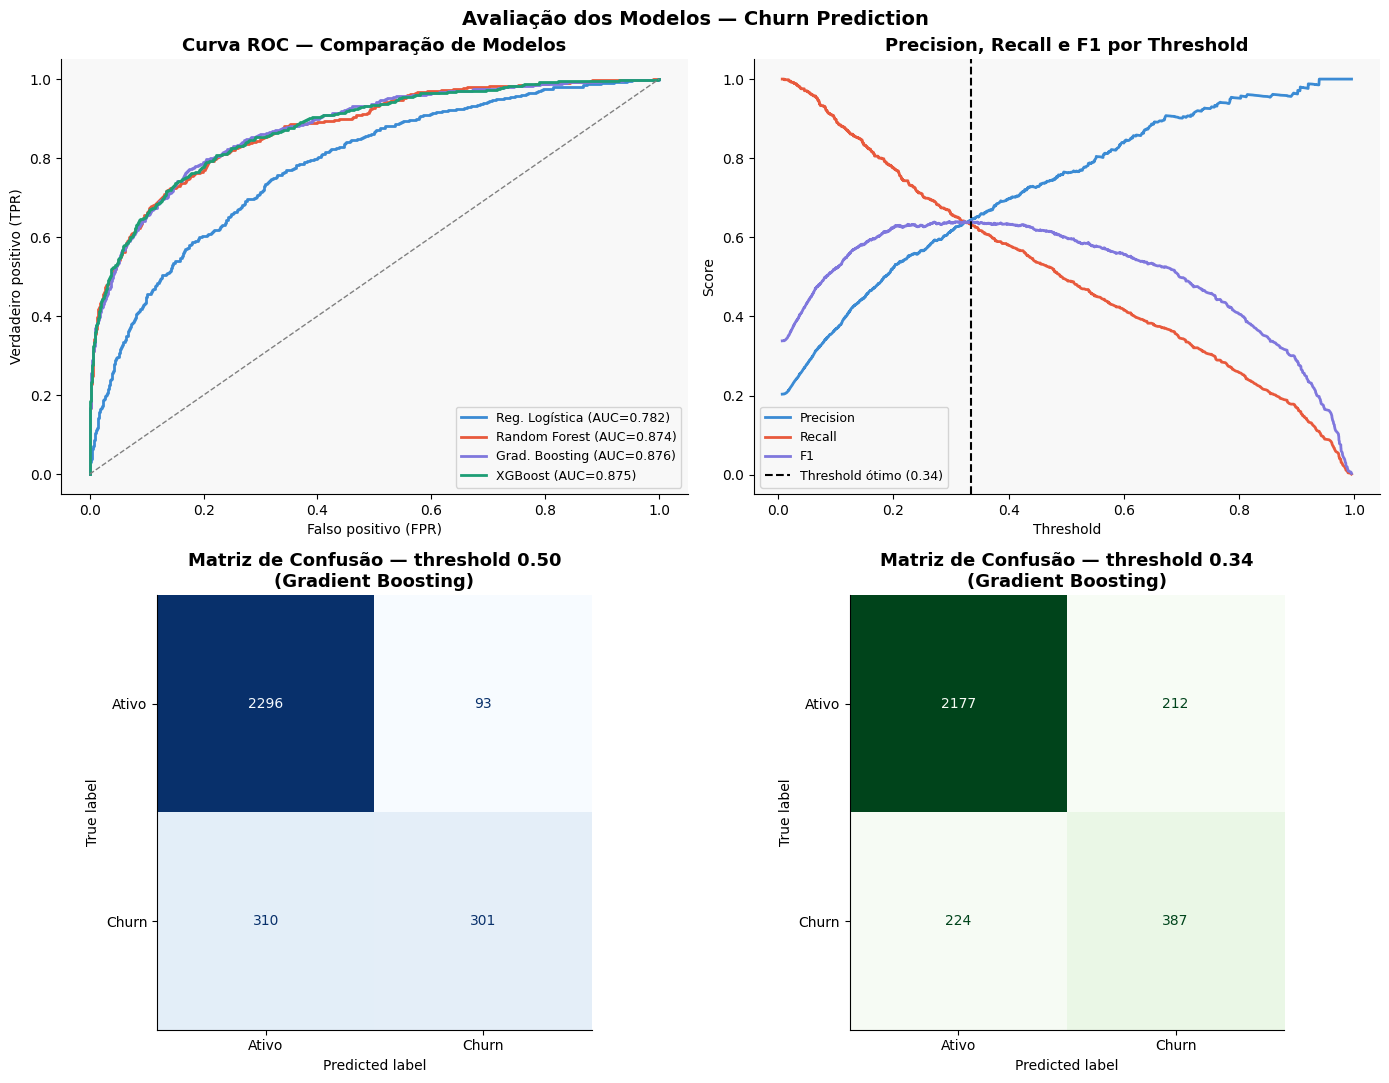

  Salvo: metricas_modelo.png


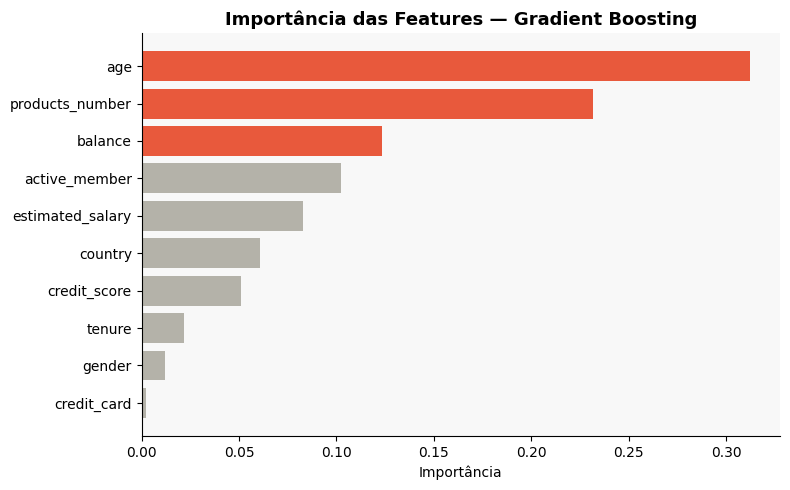

  Salvo: feature_importance.png


In [20]:
# 6. VISUALIZAÇÕES

print("6. GERANDO VISUALIZAÇÕES")


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Avaliação dos Modelos — Churn Prediction', fontsize=14, fontweight='bold')
 
# --- 6.1 Curva ROC (todos os modelos) ---
ax = axes[0, 0]
curvas = [
    ('Reg. Logística', y_prob_lr, '#3B8BD4'),
    ('Random Forest',  y_prob_rf, '#E8593C'),
    ('Grad. Boosting', y_prob_gb, '#7F77DD'),
]
if XGBOOST_OK:
    curvas.append(('XGBoost', y_prob_xgb, '#1D9E75'))
for nome, y_prob, cor in curvas:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=cor, label=f'{nome} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax.set_title('Curva ROC — Comparação de Modelos')
ax.set_xlabel('Falso positivo (FPR)')
ax.set_ylabel('Verdadeiro positivo (TPR)')
ax.legend(fontsize=9)
 
# --- 6.2 Precision-Recall e threshold ótimo ---
ax = axes[0, 1]
ax.plot(thresholds, precision_vals[:-1], color='#3B8BD4', lw=2, label='Precision')
ax.plot(thresholds, recall_vals[:-1],    color='#E8593C', lw=2, label='Recall')
ax.plot(thresholds, f1_vals,             color='#7F77DD', lw=2, label='F1')
ax.axvline(threshold_otimo, color='black', linestyle='--', lw=1.5,
           label=f'Threshold ótimo ({threshold_otimo:.2f})')
ax.set_title('Precision, Recall e F1 por Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
 
# --- 6.3 Matriz de confusão: padrão vs ajustado ---
# Mostramos a diferença entre usar threshold 0.5 e o ótimo
preds_map = {'Regressão Logística': y_pred_lr, 'Random Forest': y_pred_rf,
             'Gradient Boosting': y_pred_gb, 'XGBoost': y_pred_xgb if XGBOOST_OK else y_pred_gb}
 
ax = axes[1, 0]
cm_padrao = confusion_matrix(y_test, preds_map[melhor_nome])
disp = ConfusionMatrixDisplay(cm_padrao, display_labels=['Ativo', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — threshold 0.50\n({melhor_nome})')
 
ax = axes[1, 1]
cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)
disp2 = ConfusionMatrixDisplay(cm_ajustado, display_labels=['Ativo', 'Churn'])
disp2.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Matriz de Confusão — threshold {threshold_otimo:.2f}\n({melhor_nome})')
 
plt.tight_layout()
plt.savefig('metricas_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Salvo: metricas_modelo.png")
 
# Gráfico separado: Feature Importance
fig2, ax2 = plt.subplots(figsize=(8, 5))
fi_modelo = xgb if (XGBOOST_OK and melhor_nome == 'XGBoost') else \
            gb  if melhor_nome == 'Gradient Boosting' else rf
importancias = pd.Series(fi_modelo.feature_importances_, index=X.columns).sort_values()
cores_fi = ['#E8593C' if v >= importancias.quantile(0.75) else '#B4B2A9'
            for v in importancias.values]
ax2.barh(importancias.index, importancias.values, color=cores_fi)
ax2.set_title(f'Importância das Features — {melhor_nome}', fontsize=13, fontweight='bold')
ax2.set_xlabel('Importância')
fig2.tight_layout()
fig2.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Salvo: feature_importance.png")

In [21]:
# 7. EXPORTAR SCORE

print("7. EXPORTANDO SCORE PARA POWER BI")

# Aplicamos o melhor modelo em toda a base (não só no teste)
# para gerar o score de risco de cada cliente individualmente.
# Esse arquivo será importado no Power BI para o dashboard executivo.
X_full = df_model.drop(columns=[TARGET])
df_export = df.copy()
 
modelo_final_map = {'Regressão Logística': lr, 'Random Forest': rf,
                    'Gradient Boosting': gb, 'XGBoost': xgb if XGBOOST_OK else gb}
modelo_final = modelo_final_map[melhor_nome]
 
if melhor_nome == 'Regressão Logística':
    X_full_sc = scaler.transform(X_full)
    df_export['prob_churn'] = modelo_final.predict_proba(X_full_sc)[:, 1].round(4)
else:
    df_export['prob_churn'] = modelo_final.predict_proba(X_full)[:, 1].round(4)
 
# score_risco: escala de 0 a 1000 para facilitar leitura no dashboard
df_export['score_risco'] = (df_export['prob_churn'] * 1000).round().astype(int)
 
# Classificação em faixas usando o threshold ótimo encontrado na seção 5.
# Alto: acima do threshold ótimo (modelo prevê churn)
# Médio: zona de atenção (metade do caminho até o threshold)
# Baixo: risco baixo
limite_alto  = threshold_otimo
limite_medio = threshold_otimo / 2
df_export['faixa_risco'] = df_export['prob_churn'].apply(
    lambda p: 'Alto' if p >= limite_alto else ('Médio' if p >= limite_medio else 'Baixo')
)
# Também exportamos a predição com o threshold ajustado
df_export['pred_churn_ajustado'] = (df_export['prob_churn'] >= threshold_otimo).astype(int)
 
print(f"\nDistribuição por faixa de risco (threshold ótimo = {threshold_otimo:.2f}):")
print(df_export['faixa_risco'].value_counts())
print(f"\nScore médio (0–1000): {df_export['score_risco'].mean():.0f}")
 
df_export.to_csv('clientes_score_powerbi.csv', index=False)
print("\n  Salvo: clientes_score_powerbi.csv")

7. EXPORTANDO SCORE PARA POWER BI

Distribuição por faixa de risco (threshold ótimo = 0.34):
faixa_risco
Baixo    6591
Alto     1988
Médio    1421
Name: count, dtype: int64

Score médio (0–1000): 204

  Salvo: clientes_score_powerbi.csv


In [26]:
# 8. SALVAR MODELO PARA PRODUÇÃO (.pkl)

# Usamos joblib (preferido para modelos sklearn/xgboost) em vez
# de pickle puro porque joblib é mais eficiente para objetos grandes
# com arrays numpy, como árvores de decisão com muitos estimadores.
#
# O que salvamos:
#   modelo_final.pkl   — o modelo treinado (Random Forest, GBM ou XGBoost)
#   scaler.pkl         — o normalizador (necessário se o melhor for Logística)
#   threshold.pkl      — o threshold ótimo encontrado na seção 5
#


print("8. SALVANDO MODELO PARA PRODUÇÃO")

import joblib


 
# Salva o modelo, o scaler e o threshold num dicionário único
# para facilitar o carregamento — um arquivo só, tudo junto.
artefatos = {
    'modelo':          modelo_final,
    'scaler':          scaler,
    'threshold_otimo': threshold_otimo,
    'melhor_nome':     melhor_nome,
    'features':        list(X.columns),  # garante que as colunas estejam na ordem certa
}
joblib.dump(artefatos, 'modelo_churn.pkl')
print(f"\n  Salvo: modelo_churn.pkl")
print(f"  Conteúdo: modelo ({melhor_nome}), scaler, threshold ({threshold_otimo:.4f}), features")
 


8. SALVANDO MODELO PARA PRODUÇÃO

  Salvo: modelo_churn.pkl
  Conteúdo: modelo (Gradient Boosting), scaler, threshold (0.3354), features


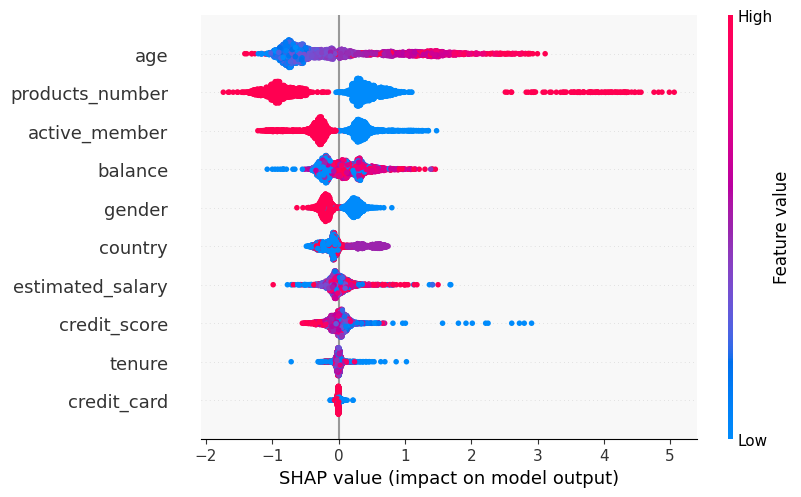

In [32]:
# 9. EXPLICABILIDADE DO MODELO

import shap

explainer = shap.Explainer(modelo_final)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)
#shap.plots.bar(shap_values)
#shap.plots.waterfall(shap_values[0])

## Interpretando a gráfico acima:

**age** é a feature mais importante. Pelo que é possível observar, clientes mais velhos aumentam fortemente a probabilidade de churn, enquanto clientes mais jovens permanecem. 
**products_number** a quantidade de produtos contratados possui forte relação com a evasão. 
**active_member** clientes inativos possuem risco significativamente maior de cancelamento.
**balance** clientes com maior saldo podem apresentar maior risco financeiro de churn
**gender** tem pouco impacto. O modelo encontrou diferença entre gêneros, mas não é dominante. 
**credit_score** scores baixos parecem aumentar o churn, mas o impacto é menor em comparação a idade e atividade. 

Em resumo, o modelo SHAP revelou que idade, atividade do cliente e quantidade de produtos são os principais fatores relacionados ao churn. Clientes mais velhos e inativos apresentaram maior probabilidade de evasão, enquanto clientes ativos demonstraram maior retenção. Além disso, clientes com maior saldo bancário mostraram risco financeiro relevante em caso de cancelamento.

In [ ]:
# 10. EXEMPLO DE USO

# O código abaixo mostra como qualquer membro do time (ou a API)
# pode usar o modelo salvo para prever churn em dados novos,
# sem precisar rodar todo o script de treinamento novamente.

print("\n  Exemplo de uso em produção:")
print("  ─" * 30)

# Simulamos 3 clientes novos para demonstrar o uso
novos_clientes = pd.DataFrame({
    'credit_score':      [650, 400, 820],
    'country':           [0, 1, 2],       # já encodado
    'gender':            [0, 1, 0],
    'age':               [35, 55, 28],
    'tenure':            [5, 1, 8],
    'balance':           [120000, 0, 85000],
    'products_number':   [2, 1, 3],
    'credit_card':       [1, 0, 1],
    'active_member':     [1, 0, 1],
    'estimated_salary':  [75000, 32000, 95000],
})
 
# Carrega os artefatos salvos (simulando uso em produção)
artefatos_carregados = joblib.load('modelo_churn.pkl')
modelo_prod    = artefatos_carregados['modelo']
scaler_prod    = artefatos_carregados['scaler']
threshold_prod = artefatos_carregados['threshold_otimo']
nome_prod      = artefatos_carregados['melhor_nome']
 
# Garante que as colunas estão na mesma ordem do treino
novos_clientes = novos_clientes[artefatos_carregados['features']]
 
# Aplica normalização apenas se o modelo for Logística
if nome_prod == 'Regressão Logística':
    dados_pred = scaler_prod.transform(novos_clientes)
else:
    dados_pred = novos_clientes
 
prob_novos  = modelo_prod.predict_proba(dados_pred)[:, 1]
pred_novos  = (prob_novos >= threshold_prod).astype(int)
risco_novos = ['Alto' if p >= threshold_prod else ('Médio' if p >= threshold_prod/2 else 'Baixo')
               for p in prob_novos]
 
resultado = novos_clientes.copy()
resultado['prob_churn']  = prob_novos.round(4)
resultado['pred_churn']  = pred_novos
resultado['faixa_risco'] = risco_novos
print(resultado[['prob_churn', 'pred_churn', 'faixa_risco']].to_string())


  Exemplo de uso em produção:
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
   prob_churn  pred_churn faixa_risco
0      0.0518           0       Baixo
1      0.9822           1        Alto
2      0.8012           1        Alto


In [24]:
print("\n" + "=" * 60)
print(f"  Melhor modelo    : {melhor_nome} (AUC = {aucs[melhor_nome]:.4f})")
print(f"  Threshold ótimo  : {threshold_otimo:.4f}")
print(f"  Gráficos salvos  : metricas_modelo.png | feature_importance.png")
print("=" * 60)


  Melhor modelo    : Gradient Boosting (AUC = 0.8756)
  Threshold ótimo  : 0.3354
  Gráficos salvos  : metricas_modelo.png | feature_importance.png
